Sukhada Bhoyar - 23070521033

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sai14karthik/nasdq-dataset")
print("Path to dataset files:", path)

100%|██████████| 126k/126k [00:00<00:00, 42.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sai14karthik/nasdq-dataset/versions/1


In [ ]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/sai14karthik/nasdq-dataset/versions/1/nasdq.csv")
df.head()

,Date,Open,High,Low,Close,Volume,InterestRate,ExchangeRate,VIX,TEDSpread,EFFR,Gold,Oil
0,2010-01-04,6.640000,6.810000,6.633333,6.746667,6514500.0,0.11,1.4419,20.04,0.17,0.12,1117.699951,81.510002
1,2010-01-05,6.643333,6.773333,6.643333,6.766667,4445100.0,0.11,1.4402,19.35,0.18,0.12,1118.099976,81.769997
2,2010-01-06,6.733333,6.786667,6.720000,6.763333,7340100.0,0.11,1.4404,19.16,0.19,0.12,1135.900024,83.180000
3,2010-01-07,6.750000,6.766667,6.630000,6.673333,8498400.0,0.11,1.4314,19.06,0.20,0.10,1133.099976,82.660004
4,2010-01-08,6.676667,6.766667,6.626667,6.743333,4347600.0,0.11,1.4357,18.13,0.20,0.11,1138.199951,82.750000


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
data = df[['Close']].values

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [ ]:
def create_sequences(data, steps=60):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i-steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data)

In [ ]:
test_input = np.concatenate((train_data[-60:], test_data))

X_test, y_test = create_sequences(test_input)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    LSTM(50),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.0076
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 1.4624e-04
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 1.4253e-04
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 1.4306e-04
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1.4659e-04
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 1.3276e-04
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 1.3498e-04
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 1.3616e-04
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.4484e-04
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1.2128e-04


In [ ]:
predictions = model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [ ]:
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.4383968387374781
RMSE: 1.8595237705332752


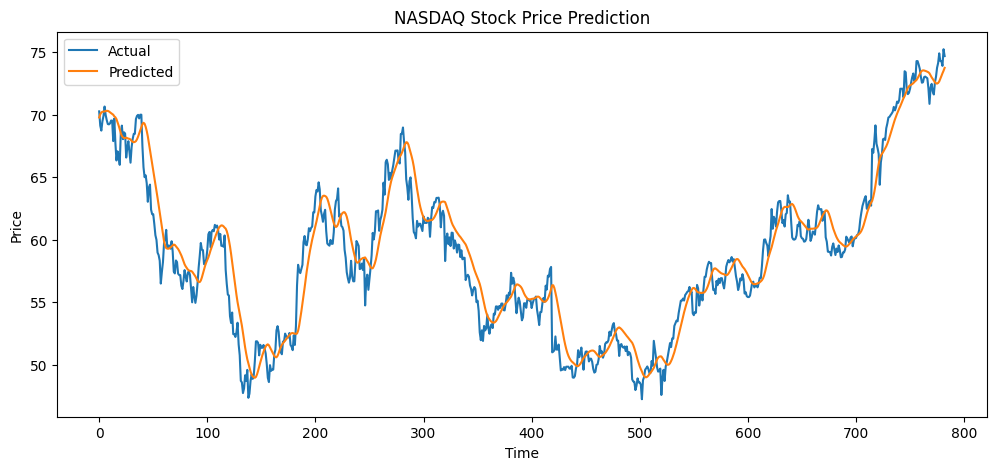

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(actual_prices, label="Actual")
plt.plot(predicted_prices, label="Predicted")
plt.title("NASDAQ Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()